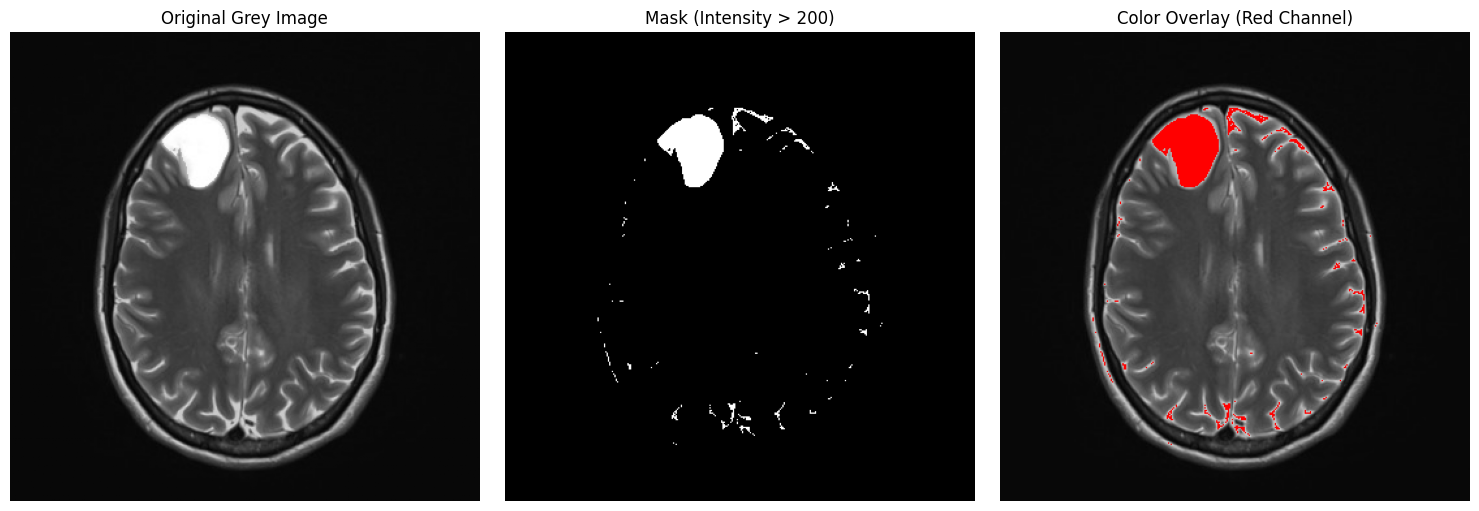

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

def create_color_overlay(image_path, threshold):
    """
    读取灰度图像，通过阈值生成掩膜，并在红色通道进行彩色叠加
    """
    # 1. 检查并读取 lab1.npy 文件
    if not os.path.exists(image_path):
        print(f"错误: 找不到文件 '{image_path}'。")
        return
        
    # 读取原始灰度图像 (假设值域是 0-255，或者是浮点数需要缩放)
    img_gray = np.load(image_path)
    
    # 如果图像不是 uint8 格式，建议先归一化到 0-255 以方便处理和显示
    if img_gray.dtype != np.uint8:
        img_gray = (255 * (img_gray - np.min(img_gray)) / np.ptp(img_gray)).astype(np.uint8)
    
    # 2. 通过设定阈值生成掩膜 (Mask)
    # I > threshold 的像素位置为 True，否则为 False
    mask = img_gray > threshold
    
    # 3. 将单通道的灰度图扩展为三通道的 RGB 彩色图
    # np.stack 在第三个维度上把三个相同的灰度图堆叠起来，形状变为 (H, W, 3)
    img_color = np.stack((img_gray, img_gray, img_gray), axis=-1)
    
    # 4. 将掩膜放置在红色通道中生成彩色叠加
    # 方法 A: 将掩膜区域直接涂成纯红色 [255, 0, 0]
    # img_color[mask] = [255, 0, 0]
    
    # 方法 B (推荐): 保留红色通道的原有纹理，将 G 和 B 通道在掩膜区域清零
    # 这样看起来就像是在原始高亮区域上蒙了一层红色玻璃，更符合医学图像叠加的习惯
    # 红色通道 (索引 0) 保持不变或设为 255
    img_color[mask, 0] = 255 
    img_color[mask, 1] = 0   # 绿色通道清零
    img_color[mask, 2] = 0   # 蓝色通道清零
    
    # ==========================================
    # 5. 显示结果
    # ==========================================
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 显示原始灰度图
    axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title('Original Grey Image')
    axes[0].axis('off')
    
    # 显示二值化掩膜 (黑白)
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title(f'Mask (Intensity > {threshold})')
    axes[1].axis('off')
    
    # 显示最终的彩色叠加图
    axes[2].imshow(img_color)
    axes[2].set_title('Color Overlay (Red Channel)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 运行程序
# ==========================================
# 阈值需要根据你的 lab1.npy 的实际直方图分布来定，这里假设为 200
create_color_overlay('lab1.npy', threshold=200)

运行后发现不能准确显示图中的白色块状区域，阈值设定过低，后面调整了阈值

还有一些别的报错，都是因为我库没装，由于没法复现，我就不放上来了